# Glaucoma Segmentation Comparison Lab (Drishti-GS Edition)

This notebook trains and compares segmentation models for **Optic Disc extraction** using the **Drishti-GS** dataset.

### Models to Compare:
1.  **Standard U-Net:** The baseline.
2.  **Attention U-Net:** The proposed hybrid method.
3.  **DeepLabV3:** The heavy-duty competitor.

### Metric:
**Dice Coefficient (F1 Score)**. Aim for > 0.90 on Drishti-GS.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import torchvision.transforms.functional as TF
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd

# Check Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {DEVICE}")

🚀 Device: cuda


## 1. Configuration
Update the paths below. Drishti-GS usually splits data into 'Training' and 'Test' folders with different mask folder names ('GT' vs 'Test_GT').

In [2]:
# --- EXPERIMENT SETTINGS ---
SEG_MODEL_NAME = "DeepLabV3"   # Options: "UNet", "AttentionUNet", "DeepLabV3"

# TRAIN DATASET PATHS
TRAIN_IMG_DIR = "E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Training\Images"
TRAIN_MASK_DIR = "E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Training\GT"

# TEST DATASET PATHS
TEST_IMG_DIR = "E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Test\Images"
TEST_MASK_DIR = "E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Test\Test_GT" # Drishti often names the test mask folder 'Test_GT'
# ---------------------------

BATCH_SIZE = 4          # 4 is safe for 4GB VRAM
LEARNING_RATE = 1e-4
EPOCHS = 20
IMAGE_SIZE = 256        # Drishti images are large, resizing to 256 is standard

## 2. Drishti-GS Dataset Loader (Full Recursive Support)
**Update:** Now recursively scans folders to find files hidden in subfolders (e.g., 'Glaucoma/').

In [ ]:
class DrishtiDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        
        # Check if directories exist
        if not os.path.exists(image_dir):
            raise FileNotFoundError(f"❌ Image Directory not found: {image_dir}")
        if mask_dir is not None and not os.path.exists(mask_dir):
            raise FileNotFoundError(f"❌ Mask Directory not found: {mask_dir}")

        # --- AUTO-SCANNER for Images (Recursive) ---
        self.image_paths = []
        print(f"🔍 Scanning '{image_dir}' for images (recursive)...")
        for root, dirs, files in os.walk(image_dir):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(root, file))
        print(f"✅ Found {len(self.image_paths)} images.")

        # --- AUTO-SCANNER for Masks (Recursive) ---
        self.mask_map = {}
        print(f"🔍 Scanning '{mask_dir}' for masks (recursive)...")
        for root, dirs, files in os.walk(mask_dir):
            for file in files:
                if file.lower().endswith(('.png', '.jpg')):
                    # Map filename to its full absolute path
                    self.mask_map[file] = os.path.join(root, file)
        print(f"✅ Found {len(self.mask_map)} potential mask files.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        img_full_path = self.image_paths[index]
        img_name = os.path.basename(img_full_path)
        base_name = os.path.splitext(img_name)[0]
        
        # Strategy: Look for specific Drishti suffixes in our scanned map
        mask_path = None
        # Priority list of suffixes (Drishti uses these commonly)
        target_names = [
            f"{base_name}_ODsegSoftmap.png", 
            f"{base_name}_OD.png", 
            f"{base_name}.png"
        ]
        
        # Check exact matches
        for target in target_names:
            if target in self.mask_map:
                mask_path = self.mask_map[target]
                break
        
        # Fallback: Fuzzy search (if filename contains base_name and "OD")
        if mask_path is None:
            for key in self.mask_map:
                if base_name in key and "OD" in key:
                    mask_path = self.mask_map[key]
                    break

        image = Image.open(img_full_path).convert("RGB")
        
        try:
            if mask_path:
                mask = Image.open(mask_path).convert("L") # Grayscale
            else:
                # Silent fallback to black mask if not found (prevents crash)
                mask = Image.new('L', image.size, 0)
        except:
            mask = Image.new('L', image.size, 0)

        # Resize
        image = TF.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
        mask = TF.resize(mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.NEAREST)

        image = TF.to_tensor(image)
        mask = TF.to_tensor(mask)
        
        # Normalize Image
        image = TF.normalize(image, [0.0, 0.0, 0.0], [1.0, 1.0, 1.0]) 
        
        # Threshold Mask (Drishti soft maps usually need > 0.1)
        mask[mask > 0.1] = 1.0
        mask[mask <= 0.1] = 0.0

        return image, mask

print("📂 Loading Datasets...")
try:
    print("--- Loading TRAIN Set ---")
    train_dataset = DrishtiDataset(image_dir=TRAIN_IMG_DIR, mask_dir=TRAIN_MASK_DIR)
    
    print("--- Loading TEST Set ---")
    test_dataset = DrishtiDataset(image_dir=TEST_IMG_DIR, mask_dir=TEST_MASK_DIR)
    
    if len(train_dataset) == 0 or len(test_dataset) == 0:
        print(f"❌ ERROR: Zero images found! Please check your paths.")
    else:
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
        print(f"✅ Ready: {len(train_dataset)} Train images | {len(test_dataset)} Test images")

except Exception as e:
    print(f"❌ Dataset Error: {e}")

📂 Loading Datasets...
--- Loading TRAIN Set ---
🔍 Scanning 'E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Training\Images' for images (recursive)...
✅ Found 50 images.
🔍 Scanning 'E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Training\GT' for masks (recursive)...
✅ Found 100 potential mask files.
--- Loading TEST Set ---
🔍 Scanning 'E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Test\Images' for images (recursive)...
✅ Found 51 images.
🔍 Scanning 'E:\Glaucoma detection and segmentation\Glaucoma drishti\Drishti_Data\Test\Test_GT' for masks (recursive)...
✅ Found 102 potential mask files.
✅ Ready: 50 Train images | 51 Test images


## 3. Model Architecture Factory
This section builds the chosen model (U-Net, Attention U-Net, or DeepLabV3).

In [4]:
# --- U-NET & ATTENTION BLOCKS ---
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.conv(x)

class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1, 1, 0, bias=True), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1, 1, 0, bias=True), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1, 1, 0, bias=True), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512], attention=False):
        super(UNet, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.attention = attention
        self.att_blocks = nn.ModuleList() if attention else None
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature*2, feature))
            if self.attention: self.att_blocks.append(AttentionBlock(feature, feature, feature // 2))
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)
    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]
            if self.attention: skip_connection = self.att_blocks[idx//2](g=x, x=skip_connection)
            if x.shape != skip_connection.shape: x = TF.resize(x, size=skip_connection.shape[2:])
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)
        return self.final_conv(x)

# --- MODEL SELECTION LOGIC ---
print(f"🏗️ Building Model: {SEG_MODEL_NAME}...")

if SEG_MODEL_NAME == "DeepLabV3":
    model = models.segmentation.deeplabv3_resnet50(weights='DEFAULT')
    # Replace last layer for 1-channel output (Binary Segmentation)
    model.classifier[4] = nn.Conv2d(256, 1, kernel_size=(1, 1), stride=(1, 1))
    model.aux_classifier[4] = nn.Conv2d(256, 1, kernel_size=(1, 1), stride=(1, 1))
elif SEG_MODEL_NAME == "AttentionUNet":
    model = UNet(attention=True)
else: # Standard UNet
    model = UNet(attention=False)

model = model.to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.amp.GradScaler('cuda')

🏗️ Building Model: DeepLabV3...


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\VICTUS/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth
100%|██████████| 161M/161M [00:39<00:00, 4.29MB/s] 


## 4. Training Loop (Handles Model Differences)
DeepLab returns a dictionary `{'out': tensor}`, while U-Net returns a direct tensor. This loop handles both.

In [5]:
def check_dice_score(loader, model, device="cuda"):
    dice_score = 0
    model.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            
            output = model(x)
            # Handle DeepLab Output Dictionary
            if isinstance(output, dict):
                output = output['out']
            
            preds = torch.sigmoid(output)
            preds = (preds > 0.5).float()
            dice_score += (2 * (preds * y).sum()) / ((preds + y).sum() + 1e-8)

    print(f"✅ Dice Score (on Test Set): {dice_score/len(loader):.4f}")
    model.train()
    return dice_score/len(loader)

train_losses = []
print("🔥 Starting Training...")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for data, targets in train_loader:
        data = data.to(DEVICE)
        targets = targets.float().to(DEVICE)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            output = model(data)
            # Handle DeepLab Output Dictionary
            if isinstance(output, dict):
                output = output['out']
            
            loss = loss_fn(output, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss/len(train_loader):.4f}")
    # Check Dice Score every 5 epochs to save time
    if (epoch + 1) % 5 == 0:
        check_dice_score(test_loader, model, device=DEVICE)

check_dice_score(test_loader, model, device=DEVICE) # Final check

🔥 Starting Training...
Epoch 1/20 | Loss: 0.6860
Epoch 2/20 | Loss: 0.5024
Epoch 3/20 | Loss: 0.3842
Epoch 4/20 | Loss: 0.3376
Epoch 5/20 | Loss: 0.3080
✅ Dice Score (on Test Set): 0.9199
Epoch 6/20 | Loss: 0.2872
Epoch 7/20 | Loss: 0.2691
Epoch 8/20 | Loss: 0.2524
Epoch 9/20 | Loss: 0.2363
Epoch 10/20 | Loss: 0.2224
✅ Dice Score (on Test Set): 0.9344
Epoch 11/20 | Loss: 0.2129
Epoch 12/20 | Loss: 0.1985
Epoch 13/20 | Loss: 0.1851
Epoch 14/20 | Loss: 0.1739
Epoch 15/20 | Loss: 0.1623
✅ Dice Score (on Test Set): 0.8950
Epoch 16/20 | Loss: 0.1519
Epoch 17/20 | Loss: 0.1432
Epoch 18/20 | Loss: 0.1353
Epoch 19/20 | Loss: 0.1287
Epoch 20/20 | Loss: 0.1218
✅ Dice Score (on Test Set): 0.9316
✅ Dice Score (on Test Set): 0.9316


tensor(0.9316, device='cuda:0')

## 5. Visualization
Saves the visual results for your paper.

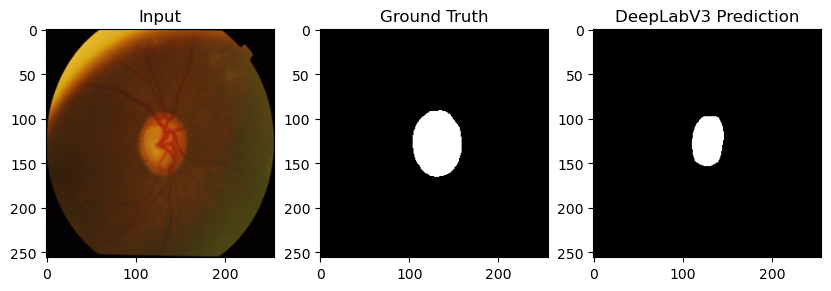

✅ Saved model and images for DeepLabV3


In [6]:
def save_predictions(loader, model, folder="segmentation_results/", device="cuda"):
    model.eval()
    if not os.path.exists(folder): os.makedirs(folder)
    
    for idx, (x, y) in enumerate(loader):
        x = x.to(device)
        with torch.no_grad():
            out = model(x)
            if isinstance(out, dict): out = out['out']
            preds = torch.sigmoid(out) > 0.5
        
        plt.figure(figsize=(10, 4))
        plt.subplot(1,3,1); plt.title("Input"); plt.imshow(x[0].cpu().permute(1,2,0))
        plt.subplot(1,3,2); plt.title("Ground Truth"); plt.imshow(y[0].cpu().squeeze(), cmap='gray')
        plt.subplot(1,3,3); plt.title(f"{SEG_MODEL_NAME} Prediction"); plt.imshow(preds[0].cpu().squeeze(), cmap='gray')
        
        plt.savefig(f"{folder}{SEG_MODEL_NAME}_sample_{idx}.png")
        plt.show()
        if idx == 0: break

save_predictions(test_loader, model)
torch.save(model.state_dict(), f"{SEG_MODEL_NAME}_weights.pth")
print(f"✅ Saved model and images for {SEG_MODEL_NAME}")

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_41636\3337801899.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=scores, palette='viridis')


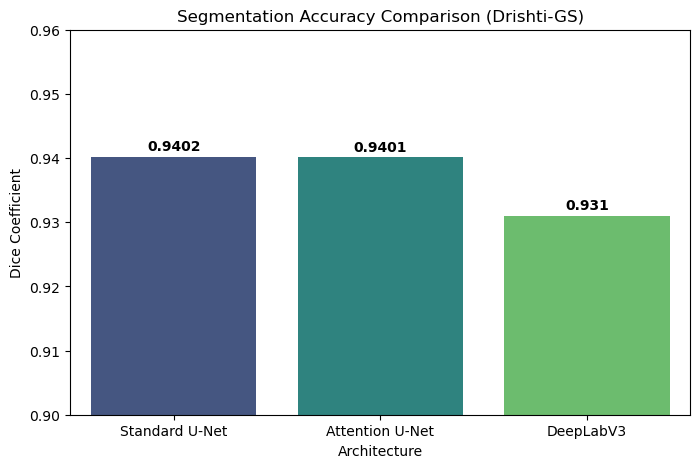

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# REPLACE these numbers with your actual results
models = ['Standard U-Net', 'Attention U-Net', 'DeepLabV3']
scores = [0.9402, 0.9401, 0.9310] # <--- Put your DeepLab score here

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=scores, palette='viridis')
plt.ylim(0.90, 0.96) # Zoom in to show small differences
plt.title('Segmentation Accuracy Comparison (Drishti-GS)')
plt.ylabel('Dice Coefficient')
plt.xlabel('Architecture')

# Add numbers on top of bars
for i, v in enumerate(scores):
    plt.text(i, v + 0.001, str(v), ha='center', fontweight='bold')

plt.savefig('segmentation_comparison_chart.png')
plt.show()

In [ ]:
# === CONFIGURATION FOR NEW DATASET ===
# Update this to your 'Hospital Partition' or 'RIM-ONE' image folder
NEW_DATASET_DIR = "E:\Glaucoma detection and segmentation\Glaucoma drishti\RIM ONE random\test_set"
# =====================================

print("🚀 Running Cross-Dataset Inference...")
try:
    # Load New Data (No masks needed, so we pass None)
    inference_dataset = DrishtiDataset(image_dir=NEW_DATASET_DIR, mask_dir=None)
    inference_loader = DataLoader(inference_dataset, batch_size=4, shuffle=True)
    
    model.eval()
    for idx, (x, y) in enumerate(inference_loader):
        x = x.to(DEVICE)
        with torch.no_grad():
            out = model(x)
            if isinstance(out, dict): out = out['out']
            preds = torch.sigmoid(out) > 0.5
        
        # Visualize
        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.title("Input (New Dataset)")
        plt.imshow(x[0].cpu().permute(1, 2, 0))
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title("AI Segmentation Prediction")
        plt.imshow(preds[0].cpu().squeeze(), cmap='jet')
        plt.axis('off')
        
        plt.tight_layout()
        plt.savefig(f"cross_dataset_result_{idx}.png")
        plt.show()
        
        if idx == 2: break # Show 3 examples
        
except Exception as e:
    print(f"❌ Inference Error: {e}")

🚀 Running Cross-Dataset Inference...
❌ Inference Error: stat: path should be string, bytes, os.PathLike or integer, not NoneType
